## Settings & imports

In [1]:
import numpy as np
import pandas as pd
import os
# import torch
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import string
# from torch import nn
# from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
import csv

In [2]:
object_name = 'Konstytucja_prediction' #Konstytucja_indicators / Konstytucja_prediction

In [3]:
keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'logarithm' # none / normalization / logarithm

collapse = False

columns_to_keep_inks = {
                        'Konstytucja_indicators' : [
                                                     'Al',
                                                     'S',
                                                     'Cr',
                                                     'Mn',
                                                     'Co',
                                                     'Cu',
                                                     'Zn',
                                                     'Pb'
                                                            ],
                        'Konstytucja_prediction' : [
                                                     'Al',
                                                     'S',
                                                     'Cr',
                                                     'Mn',
                                                     'Co',
                                                     'Cu',
                                                     'Zn',
                                                     'Pb'
                                                            ],
    
                        }

columns_to_keep_inds = { 
                        'Konstytucja_indicators' : [
                                                    'Al_inds',
                                                    'S_inds',
                                                    'Cr_inds',
                                                    'Mn_inds',
                                                    'Co_inds',
                                                    'Cu_inds',
                                                    'Zn_inds',
                                                    'Pb_inds'
                                                            ],
                        'Konstytucja_prediction' : [
                                                    'Al_inds',
                                                    'S_inds',
                                                    'Cr_inds',
                                                    'Mn_inds',
                                                    'Co_inds',
                                                    'Cu_inds',
                                                    'Zn_inds',
                                                    'Pb_inds'
                                                            ],
    
                        }

In [4]:
data_path = {'Konstytucja_indicators' : '../data/Lipiec_2024.xlsx',
            'Konstytucja_prediction' : '../results/Konstytucja/prediction_from_model_regression_2024_09_28_23_53_51'}

figures_path = {'Konstytucja_indicators' : '../results/visualisations/Konstytucja_indicators/',
                'Konstytucja_prediction' : '../results/visualisations/Konstytucja_prediction/'
               }

ground_truth_path = {'Konstytucja_indicators' : '../data/opis.xlsx',
                    'Konstytucja_prediction' : '../data/opis.xlsx'}

## Loading the data

In [5]:
# if object_name == 'Books':
#     if real_or_simulated == 'simulated':
#         inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
#     elif real_or_simulated == 'real':
#         inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
#     elif real_or_simulated == 'all':
#         inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

# elif object_name == 'Documents_XVIII_century':
#     inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(3931, 4742))
#     inds_df.columns = [x.split('.')[0]+'_inds' for x in list(inds_df.columns)]    
    
if object_name == 'Konstytucja_indicators':
    df = pd.ExcelFile(data_path[object_name])
    df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(1, 3945))
    df.columns = [x.split('.')[0]+'_inds' for x in list(df.columns)]
    df.drop(index=[0], inplace=True)
    
elif object_name == 'Konstytucja_prediction':
    inks = np.loadtxt(data_path[object_name], delimiter=',')
    df = pd.DataFrame(data=inks, columns=columns_to_keep_inks[object_name])

## Preprocessing

In [6]:
df.reset_index(drop=True, inplace=True)

In [7]:
#################################################

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [8]:
if object_name == 'Konstytucja_indicators':
    df = df[columns_to_keep_inds[object_name]]
elif object_name == 'Konstytucja_prediction':
    df = df[columns_to_keep_inks[object_name]]

2. Let's check if there are any rows with missing values.

In [9]:
(df.shape[0] - df.dropna().shape[0])/df.shape[0]

0.0

### Collapsing 15 copies to one data point (optional)

In [10]:
if collapse:
    df = df.groupby(np.arange(len(df))//15).mean()

### Converting to np.array

In [11]:
X = np.array(df.values)

### Normalizing / taking logarithm

In [12]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [13]:
if preprocessing_method == 'normalization':

    X = (X - np.min(X, axis=0))/np.std(X, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X = adjusted_log_transform(X)
    
elif preprocessing_method == 'none':
    
    pass

/tmp/ipykernel_20429/1324458353.py:2: RuntimeWarning: invalid value encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


## Ground truth

In [14]:
df = pd.ExcelFile(data_path['Konstytucja_indicators'])
class_df = df.parse('Arkusz1', header=0, usecols=range(31,32), skiprows=range(1, 3946))
class_df.columns = ['Code']
class_df['Code'] = class_df['Code'].apply(lambda x: x.replace('.', ''))
class_df['Code'] = class_df['Code'].apply(lambda x: x[:-1] if x.endswith(('D', 'y',)) else x)
class_df['Code'] = class_df['Code'].astype(str)

In [15]:
class_names_dict = {'podpis - Małachowski' : 'Małachowski',
                   'podpis -Małachowski' : 'Małachowski',
                   'podpis - Kossakowski' : 'Kossakowski',
                    'podpis - Jabłonowski' : 'Jabłonowski',
                    'podpis - Szydłowski' : 'Szydłowski',
                    'podpis - Kwilecki' : 'Kwilecki',      
                    'podpis - Plater': 'Plater', 
                    'podpis - Stroynowski' : 'Stroynowski', 
                    'podpis - Potocki' : 'Potocki',
                    'podpis - Zboiński' : 'Zboiński',
                    'podpis - Nowowiejski' : 'Nowowiejski',
                    'podpis - Radzicki' : 'Radzicki',
                    'podpis - Zabiełło' : 'Zabiełło',
                    'podpis - Puttkamer' : 'Puttkamer',
                    'podpis - Sapieha' : 'Sapieha',
                    'treść' : 'treść',
                    'poprawka' : 'poprawka',
                    'poprawka ': 'poprawka',
                    'papier' : 'papier',
                    'oblatowanie' : 'oblatowanie',
                    'komentarz' : 'komentarz',
                    'plama' : 'plama'
                    }

In [16]:
ground_truth_df = pd.ExcelFile(ground_truth_path[object_name])
ground_truth_df = ground_truth_df.parse('KONSTYTUCJA', header=1, usecols=range(1,5))
ground_truth_df.columns = ['Code', 'Source', 'Page', 'Class name']
ground_truth_df['Code'] = ground_truth_df['Code'].apply(lambda x: x[:-1] if x.endswith(('A', 'B', 'C')) else x)
ground_truth_df.drop(columns=['Source', 'Page'], inplace=True)
ground_truth_df['Code'] = ground_truth_df['Code'].astype(str)
ground_truth_df['Class name'] = ground_truth_df['Class name'].map(class_names_dict)
ground_truth_df.drop_duplicates(['Code'], inplace=True)

In [17]:
class_df = class_df.merge(ground_truth_df, on='Code', how='left')

In [18]:
# with pd.option_context('display.max_rows', 1000, 'display.max_columns', 10):
#     display(class_df)

## Analysis

### PCA

In [19]:
if collapse:
    y = [class_df['Class name'].iloc[15*i] for i in range(int(X.shape[0]))]
    y = [str(y) for y in y]
else:
    y = class_df['Class name']
    y = [str(y) for y in y]

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [21]:
%matplotlib notebook

<IPython.core.display.Javascript object>


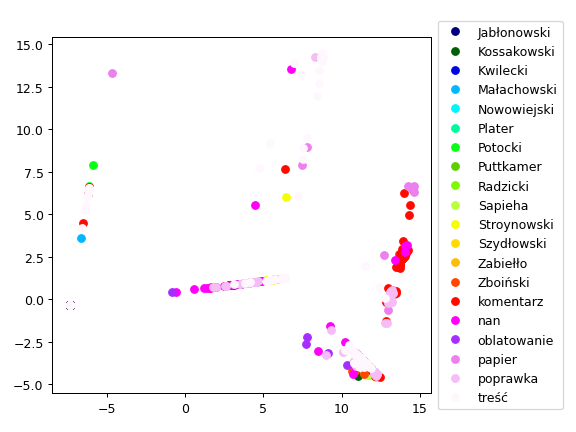

In [22]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_pca.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:2], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

<IPython.core.display.Javascript object>


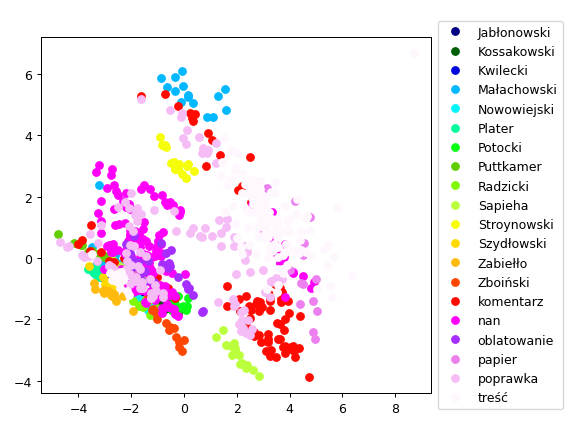

In [22]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_pca.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:2], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

<IPython.core.display.Javascript object>


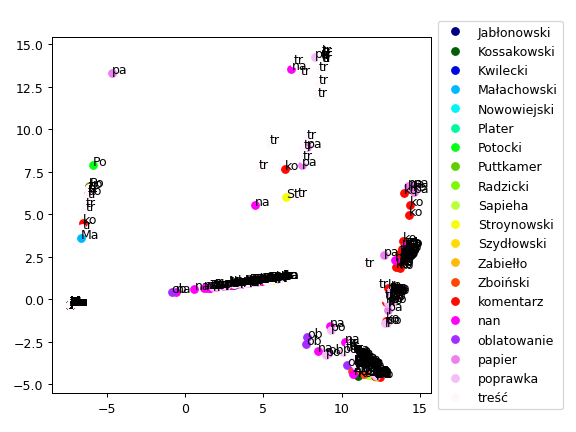

In [25]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_pca.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:2], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

<IPython.core.display.Javascript object>


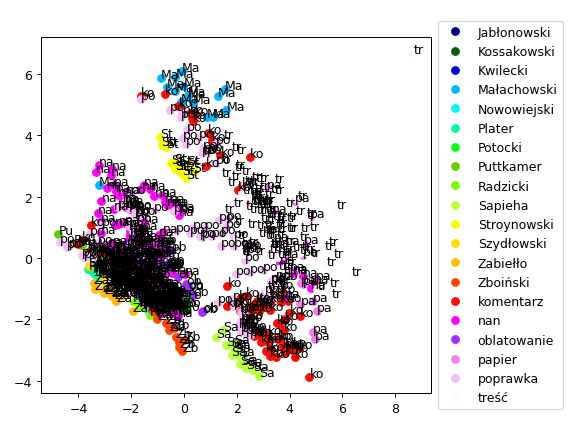

In [23]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_pca_0 = [X_pca[i, 0] for i in range(X_pca.shape[0]) if y[i] == label]
    x_pca_1 = [X_pca[i,1] for i in range(X_pca.shape[0]) if y[i] == label]
    plt.plot(x_pca_0, x_pca_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_pca.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:2], (X_pca[i, 0], X_pca[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

### tSNE to check something

In [26]:
if collapse:
    y = [class_df['Class name'].iloc[15*i] for i in range(int(X.shape[0]))]
    y = [str(y) for y in y]
else:
    y = class_df['Class name']
    y = [str(y) for y in y]

In [27]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

<IPython.core.display.Javascript object>


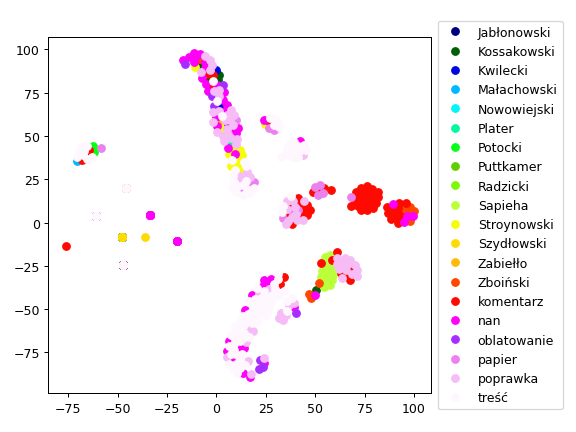

In [28]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_tsne.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:1], (X_tsne[i, 0], X_tsne[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

<IPython.core.display.Javascript object>


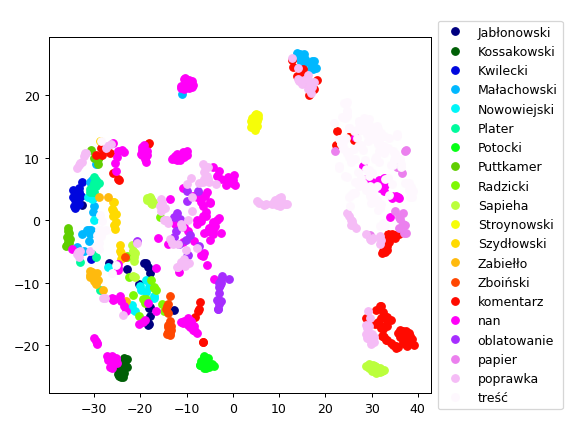

In [26]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
# for i in range(X_tsne.shape[0]):
#     if isinstance(y[i], float):
#         pass
#     else:
#         plt.annotate(y[i][:1], (X_tsne[i, 0], X_tsne[i,1]))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

<IPython.core.display.Javascript object>


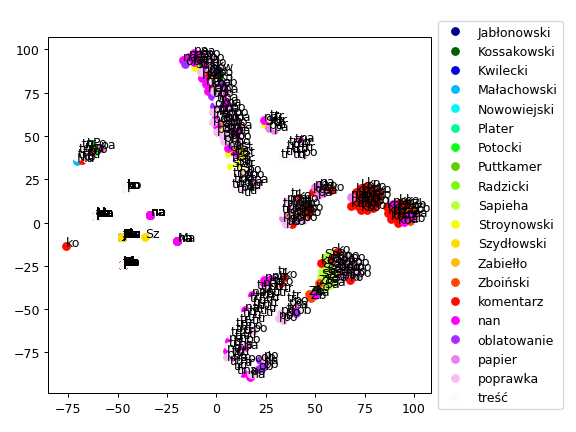

In [32]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_tsne.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:2], (X_tsne[i, 0], X_tsne[i,1]))
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

<IPython.core.display.Javascript object>


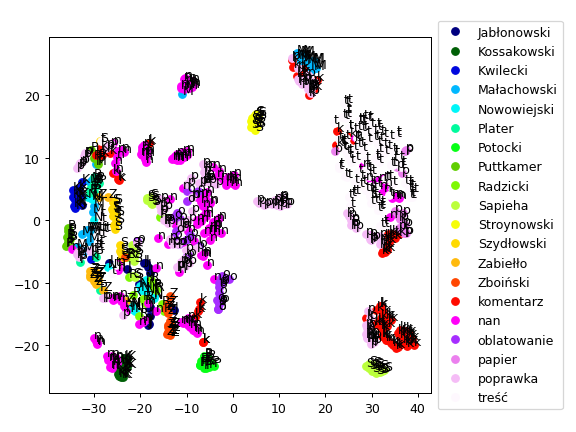

In [27]:
if collapse:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
else:
    color = cm.gist_ncar(np.linspace(0, 1, len(set(y))))
    
for label_nr, label in enumerate(sorted(set(y))):
    x_tsne_0 = [X_tsne[i, 0] for i in range(X_tsne.shape[0]) if y[i] == label]
    x_tsne_1 = [X_tsne[i,1] for i in range(X_tsne.shape[0]) if y[i] == label]
    plt.plot(x_tsne_0, x_tsne_1, 'o',label = label, color=color[label_nr])
    
for i in range(X_tsne.shape[0]):
    if isinstance(y[i], float):
        pass
    else:
        plt.annotate(y[i][:1], (X_tsne[i, 0], X_tsne[i,1]))
        
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()

## Drawing random records from the same group

## Clustering

In [ ]:
ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)
    two_means = cluster.MiniBatchKMeans(
        n_clusters=params["n_clusters"],
        random_state=params["random_state"],
    )
    ward = cluster.AgglomerativeClustering(
        n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity
    )
    spectral = cluster.SpectralClustering(
        n_clusters=params["n_clusters"],
        eigen_solver="arpack",
        affinity="nearest_neighbors",
        random_state=params["random_state"],
    )
    dbscan = cluster.DBSCAN(eps=params["eps"])
    hdbscan = cluster.HDBSCAN(
        min_samples=params["hdbscan_min_samples"],
        min_cluster_size=params["hdbscan_min_cluster_size"],
        allow_single_cluster=params["allow_single_cluster"],
    )
    optics = cluster.OPTICS(
        min_samples=params["min_samples"],
        xi=params["xi"],
        min_cluster_size=params["min_cluster_size"],
    )
    affinity_propagation = cluster.AffinityPropagation(
        damping=params["damping"],
        preference=params["preference"],
        random_state=params["random_state"],
    )
    average_linkage = cluster.AgglomerativeClustering(
        linkage="average",
        metric="cityblock",
        n_clusters=params["n_clusters"],
        connectivity=connectivity,
    )
    birch = cluster.Birch(n_clusters=params["n_clusters"])
    gmm = mixture.GaussianMixture(
        n_components=params["n_clusters"],
        covariance_type="full",
        random_state=params["random_state"],
    )

    clustering_algorithms = (
        ("MiniBatch\nKMeans", two_means),
        ("Affinity\nPropagation", affinity_propagation),
        ("MeanShift", ms),
        ("Spectral\nClustering", spectral),
        ("Ward", ward),
        ("Agglomerative\nClustering", average_linkage),
        ("DBSCAN", dbscan),
        ("HDBSCAN", hdbscan),
        ("OPTICS", optics),
        ("BIRCH", birch),
        ("Gaussian\nMixture", gmm),
    )